In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, confusion_matrix,precision_recall_curve,roc_curve)
from scipy.stats import ks_2samp
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

In [15]:
df = pd.read_csv('../Telco-Customer-Churn-cleaned.csv')
print(df.shape)
print(df['Churn'].value_counts())

(7043, 31)
Churn
0    5174
1    1869
Name: count, dtype: int64


In [16]:
X=df.drop(columns=['Churn'])
Y=df['Churn']

print(f"Features:{X.shape}")
print(f"target:{Y.shape}")

Features:(7043, 30)
target:(7043,)


In [19]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)
print(f"Training size:{X_train.shape}")
print(f"Testing size:{X_test.shape}")
print(f"Churn rate in training:{Y_train.mean():.2}")
print(f"Churn rate in testing:{Y_test.mean():.2}")

Training size:(5634, 30)
Testing size:(1409, 30)
Churn rate in training:0.27
Churn rate in testing:0.27


In [20]:
smote = SMOTE(random_state=42)
X_train_smote,Y_train_smote=smote.fit_resample(X_train,Y_train)

print(f"Before smote:{Y_train.value_counts().to_dict()}")
print(f"After smote:{pd.Series(Y_train_smote).value_counts().to_dict()}")

Before smote:{0: 4139, 1: 1495}
After smote:{0: 4139, 1: 4139}


In [26]:
def evaluate_model(model_name,y_test,y_pred_prob):
    auc=roc_auc_score(y_test,y_pred_prob)
    
    churned_prob=y_pred_prob[y_test==1]
    not_churned_prob=y_pred_prob[y_test==0]
    ks_stat,_=ks_2samp(churned_prob,not_churned_prob)
    
    y_pred=(y_pred_prob>=0.5).astype(int)
    cm=confusion_matrix(y_test,y_pred)
    
    print(model_name)
    print(f"AUC-ROC:{auc:.4f}")
    print(f"KS Statistic:{ks_stat:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    
    return {'model':model_name,'auc':auc,'ks_stat':ks_stat}


In [27]:
results=[]

lr=LogisticRegression(random_state=42,max_iter=1000)
lr.fit(X_train,Y_train)
r=evaluate_model("Lr-No Handling imbalance",Y_test,lr.predict_proba(X_test)[:,1])
results.append(r);

rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,Y_train)
r=evaluate_model("RF-No imbalance handling",Y_test,rf.predict_proba(X_test)[:,1])
results.append(r)

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, Y_train)
r = evaluate_model("XGB - No Handling imbalance", Y_test, xgb.predict_proba(X_test)[:,1])
results.append(r)

lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, Y_train)
r = evaluate_model("LGBM - No Handling imbalance", Y_test, lgbm.predict_proba(X_test)[:,1])
results.append(r)

Lr-No Handling imbalance
AUC-ROC:0.8427
KS Statistic:0.5246
Confusion Matrix:
[[926 109]
 [165 209]]
RF-No imbalance handling
AUC-ROC:0.8253
KS Statistic:0.5094
Confusion Matrix:
[[916 119]
 [184 190]]
XGB - No Handling imbalance
AUC-ROC:0.8224
KS Statistic:0.5071
Confusion Matrix:
[[902 133]
 [188 186]]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
LGBM - No Handling imbalance
AUC-ROC:0.8362
KS Statistic:0.5

In [29]:

lr_cw=LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000)
lr_cw.fit(X_train,Y_train)
r=evaluate_model("Lr-Class Weights",Y_test,lr_cw.predict_proba(X_test)[:,1])
results.append(r)

rf_cw=RandomForestClassifier(class_weight='balanced',random_state=42)
rf_cw.fit(X_train,Y_train)
r=evaluate_model("RF-Class Weights",Y_test,rf_cw.predict_proba(X_test)[:,1])
results.append(r)

xgb_cw = XGBClassifier(scale_pos_weight=2.77,random_state=42, eval_metric='logloss')
xgb_cw.fit(X_train, Y_train)
r = evaluate_model("XGB - Class Weights", Y_test, xgb_cw.predict_proba(X_test)[:,1])
results.append(r)

lgbm_cw = LGBMClassifier(class_weight='balanced',random_state=42)
lgbm_cw.fit(X_train, Y_train)
r = evaluate_model("LGBM - Class Weights", Y_test, lgbm_cw.predict_proba(X_test)[:,1])
results.append(r)

Lr-Class Weights
AUC-ROC:0.8421
KS Statistic:0.5164
Confusion Matrix:
[[744 291]
 [ 79 295]]
RF-Class Weights
AUC-ROC:0.8224
KS Statistic:0.5033
Confusion Matrix:
[[927 108]
 [188 186]]
XGB - Class Weights
AUC-ROC:0.8194
KS Statistic:0.5059
Confusion Matrix:
[[807 228]
 [114 260]]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000306 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LGBM - Class Weights
AUC-ROC:0.8347
KS Statistic:0.5219
Confusion Matrix:
[[790 245]
 

In [31]:
lr_sm = LogisticRegression(random_state=42, max_iter=1000)
lr_sm.fit(X_train_smote, Y_train_smote)
r = evaluate_model("LR - SMOTE", Y_test, lr_sm.predict_proba(X_test)[:,1])
results.append(r)

rf_sm = RandomForestClassifier(random_state=42)
rf_sm.fit(X_train_smote, Y_train_smote)
r = evaluate_model("RF - SMOTE", Y_test, rf_sm.predict_proba(X_test)[:,1])
results.append(r)

xgb_sm = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_sm.fit(X_train_smote, Y_train_smote)
r = evaluate_model("XGB - SMOTE", Y_test, xgb_sm.predict_proba(X_test)[:,1])
results.append(r)

lgbm_sm = LGBMClassifier(random_state=42)
lgbm_sm.fit(X_train_smote, Y_train_smote)
r = evaluate_model("LGBM - SMOTE", Y_test, lgbm_sm.predict_proba(X_test)[:,1])
results.append(r)

LR - SMOTE
AUC-ROC:0.8323
KS Statistic:0.5152
Confusion Matrix:
[[855 180]
 [125 249]]
RF - SMOTE
AUC-ROC:0.8215
KS Statistic:0.5187
Confusion Matrix:
[[864 171]
 [139 235]]
XGB - SMOTE
AUC-ROC:0.8177
KS Statistic:0.5113
Confusion Matrix:
[[868 167]
 [138 236]]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4139, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 8278, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LGBM - SMOTE
AUC-ROC:0.8334
KS Statistic:0.5115
Confusion Matrix:
[[865 170]
 [142 232]]


In [33]:
results_df=pd.DataFrame(results)
results_df=results_df.sort_values('auc',ascending=False)
print(results_df.head(5))
results_df.to_csv('../model_results.csv',index=False)

                   model       auc   ks_stat
0       Lr-Class Weights  0.842099  0.516397
4       Lr-Class Weights  0.842099  0.516397
7   LGBM - Class Weights  0.834736  0.521902
3   LGBM - Class Weights  0.834736  0.521902
11          LGBM - SMOTE  0.833391  0.511543


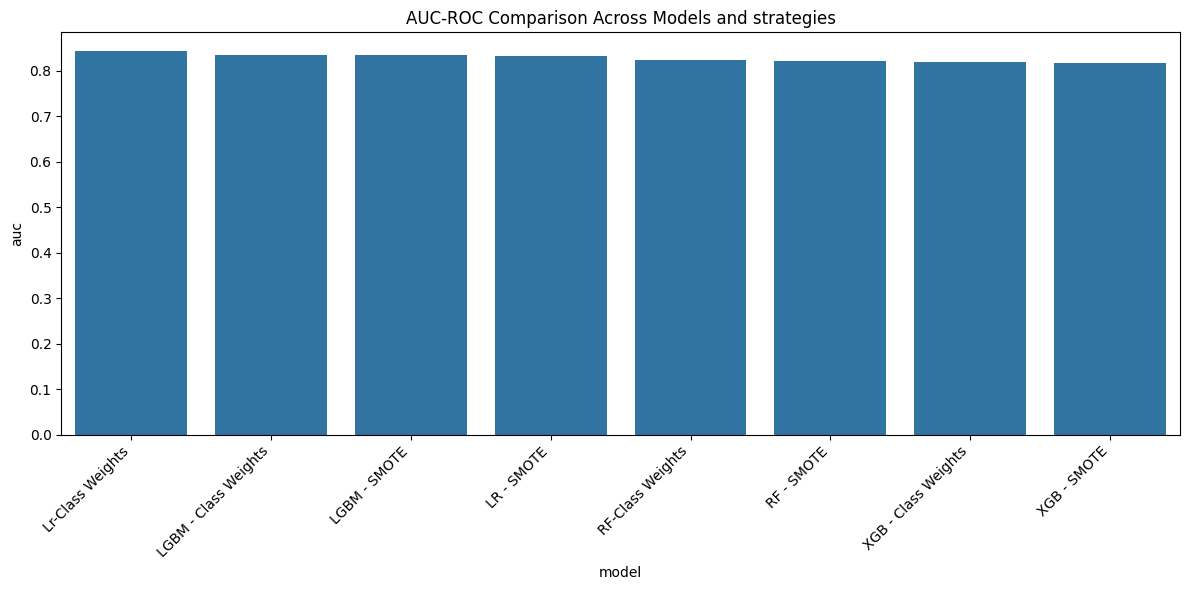

In [35]:
plt.figure(figsize=(12,6))
sns.barplot(data=results_df,x='model',y='auc')
plt.xticks(rotation=45,ha='right')
plt.title('AUC-ROC Comparison Across Models and strategies')
plt.tight_layout()
plt.savefig('../outputs/plots/model_comparison.png')
plt.show()